# PYTHON FOR ESTIMATION

## Import Lieraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.stats.api as sms
from scipy.stats import t 
from scipy.stats import norm
from statsmodels.stats.proportion import proportion_confint

## Confidence Intervals for Proportions

In [2]:
proportion_confint(count=778,
                   nobs=1497,
                   alpha=0.05, method='normal')

(0.4943973906940667, 0.545014766954564)

In [3]:
proportion_confint(778, 1497, method='wilson')

(0.4943793119474541, 0.5449319688365669)

### The t Destribution

np.float64(0.9749999859839616)

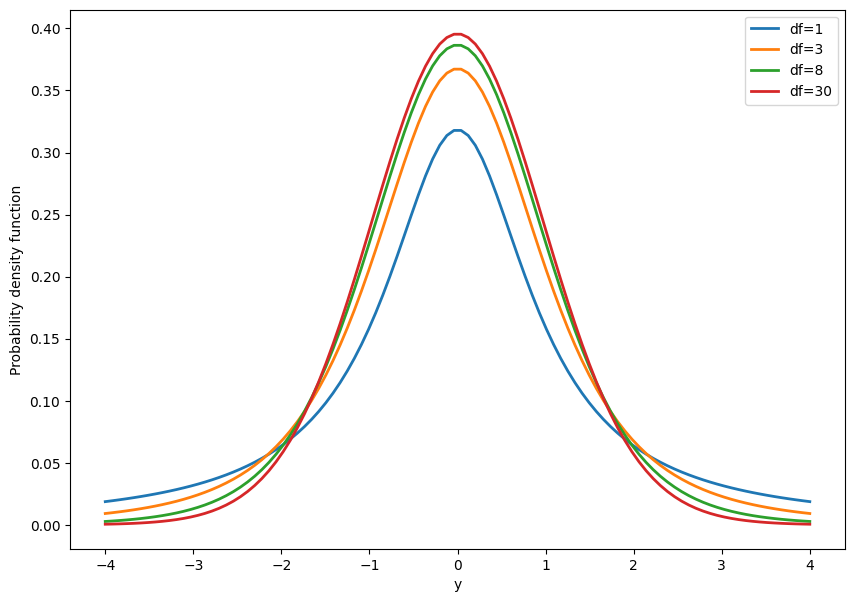

In [14]:
df = np.array([1,3,8,30])
y = np.linspace(-4, 4, 100)

def t_pdfs():
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    for i in range(len(df)):
        ax.plot(y, t.pdf(y, df[i]), lw=2)
        ax.legend(['df=1', 'df=3', 'df=8', 'df=30', 'normal'], loc='upper right')

t_pdfs()
plt.xlabel('y')
plt.ylabel('Probability density function');

df = np.array([1,10,30,100,1000,10000])
t.pdf(0.975, df)
t.cdf(1.960201, 10000)

### Confidence Intervals for Means

In [18]:
Anor = pd.read_csv('http://stat4ds.rwth-aachen.de/data/Anorexia.dat', sep='\s+')
Anor

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13508\3596477328.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  Anor = pd.read_csv('http://stat4ds.rwth-aachen.de/data/Anorexia.dat', sep='\s+')


,subject,therapy,before,after
0,1,cb,80.5,82.2
1,2,cb,84.9,85.6
2,3,cb,81.5,81.4
3,4,cb,82.6,81.9
4,5,cb,79.9,76.4
...,...,...,...,...
67,68,c,84.4,84.7
68,69,c,79.6,81.4
69,70,c,77.5,81.2
70,71,c,72.3,88.2


In [20]:
change = Anor['after'] - Anor['before']
Anor['change'] = change

In [21]:
Anor.head()

,subject,therapy,before,after,change
0,1,cb,80.5,82.2,1.7
1,2,cb,84.9,85.6,0.7
2,3,cb,81.5,81.4,-0.1
3,4,cb,82.6,81.9,-0.7
4,5,cb,79.9,76.4,-3.5


In [22]:
Anor.loc[Anor['therapy'] == 'cb']['change'].describe()

count    29.000000
mean      3.006897
std       7.308504
min      -9.100000
25%      -0.700000
50%       1.400000
75%       3.900000
max      20.900000
Name: change, dtype: float64

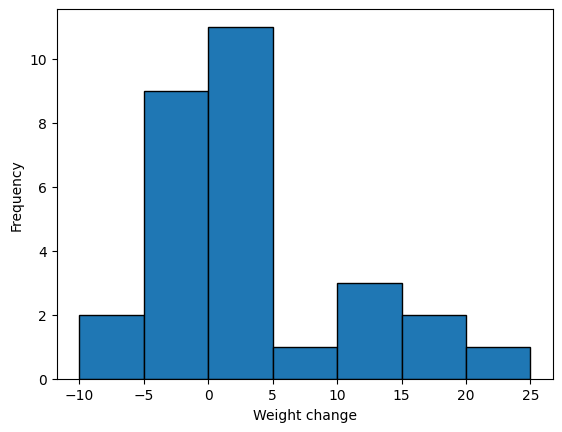

In [24]:
bins = list(range(-10, 30, 5))

plt.hist(Anor.loc[Anor['therapy'] == 'cb']['change'], bins=bins, edgecolor='k')
plt.xlabel('Weight change')
plt.ylabel('Frequency');

In [31]:
changeCB = Anor.loc[Anor['therapy'] == 'cb']['change']

sms.DescrStatsW(changeCB).tconfint_mean() # alpha=0.5 default

(np.float64(0.2268901583587759), np.float64(5.7869029450895))

In [32]:
sms.DescrStatsW(changeCB).tconfint_mean(alpha=0.1)

(np.float64(0.6981978674058436), np.float64(5.315595236042433))

### Confidence Intervals Comparing Means and Comparing Proportions